In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 

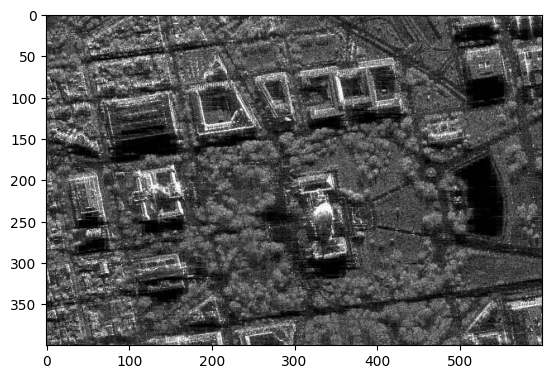

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt

image = cv.imread('sar_1_gray.jpg', cv.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.show()

2. постройте гистограмму

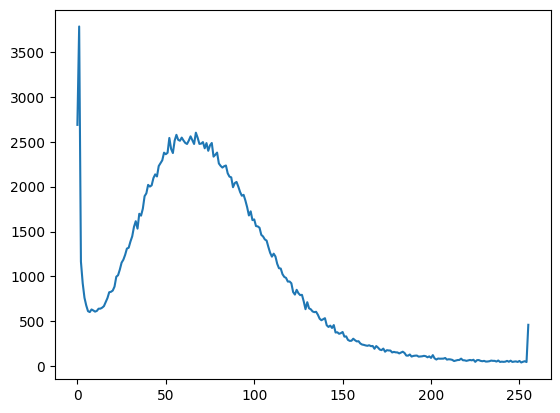

In [4]:
hist = cv.calcHist([image], [0], None, [256], [0, 256])
hist = hist.flatten()
plt.plot(hist)

3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

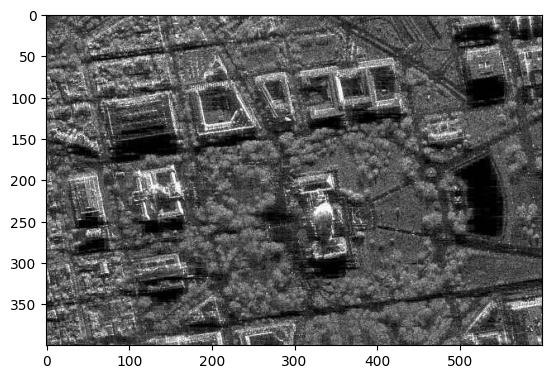

In [5]:
import numpy as np
max_intensity = np.max(image)
gamma = 1.1
image_gamma_corrected = np.array(max_intensity*(image / max_intensity) ** (1 / gamma), dtype = 'uint8')
plt.imshow(image_gamma_corrected, cmap='gray')
plt.show()

4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

MSE: 52.22372083333333
SSIM: 0.9928997670296753


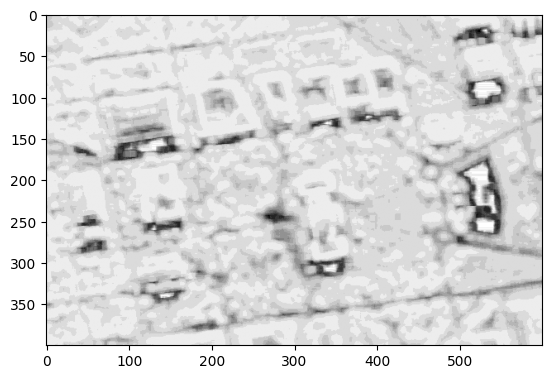

In [6]:
from skimage.metrics import structural_similarity, mean_squared_error

mse = mean_squared_error(image, image_gamma_corrected)
print("MSE: {}".format(mse))

(ssim, diff) = structural_similarity(image, image_gamma_corrected, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))
plt.imshow(diff, cmap='gray')
plt.show()



5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

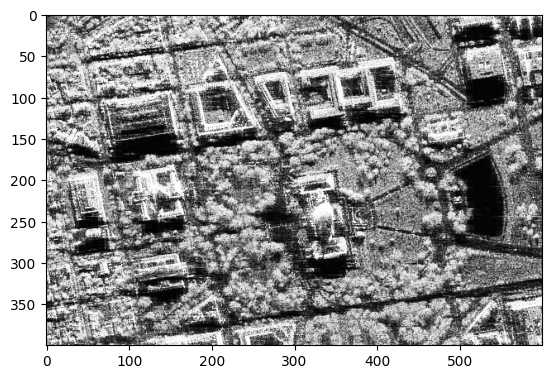

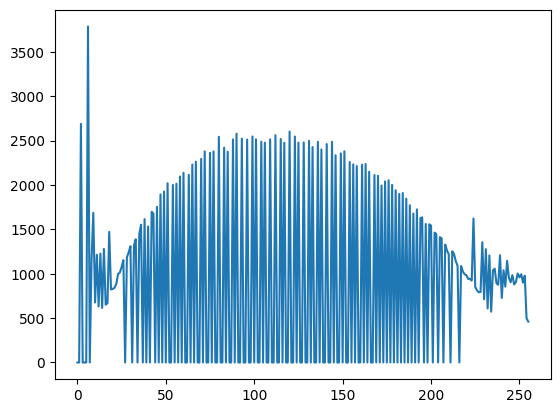

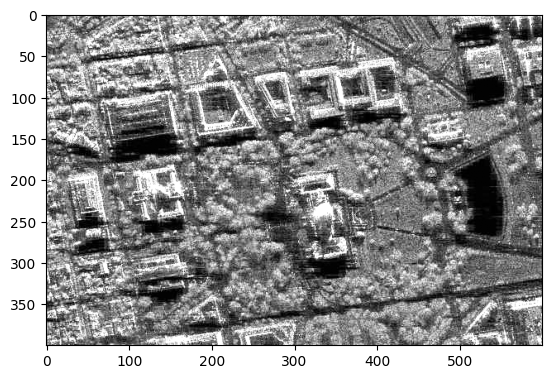

In [7]:
hist_norm = hist / image.size
cdf = hist_norm.cumsum()
cdf_scaled = np.uint8(255 * cdf)
image_eq = cdf_scaled[image]
plt.imshow(image_eq, cmap='gray')
plt.show()
eq_hist = cv.calcHist([image_eq], [0], None, [256], [0, 256])
plt.plot(eq_hist)
plt.show()

levels = np.arange(256)
srcMean = np.sum(levels * hist.flatten()) / image.size
srcStd = np.sqrt(np.sum(hist.flatten() * (levels - srcMean) ** 2) / image.size)
eqMean = np.sum(levels * eq_hist.flatten()) / image.size
eqStd = np.sqrt(np.sum(eq_hist.flatten() * (levels - eqMean) ** 2) / image.size)
image_stat_corr = np.clip((image - srcMean) * (eqStd / srcStd) + eqMean, 0, 255).astype('uint8')
plt.imshow(image_stat_corr, cmap='gray')
plt.show()

6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

127.0

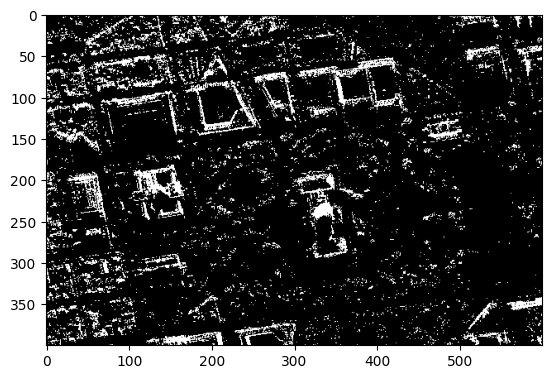

In [10]:
ret, image_thresh = cv.threshold(image, 127, 255, cv.THRESH_BINARY)
plt.imshow(image_thresh, cmap='gray')
ret

55.0

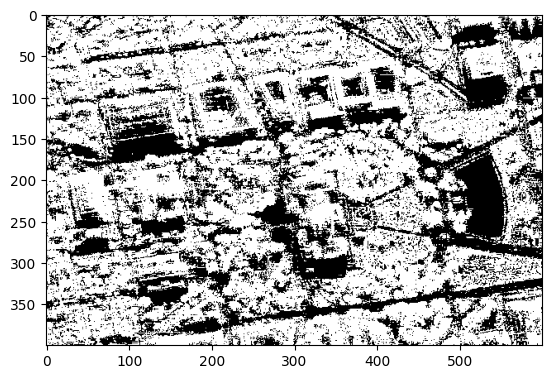

In [11]:
ret, image_thresh = cv.threshold(image, 55, 255, cv.THRESH_BINARY)
plt.imshow(image_thresh, cmap='gray')
ret

200.0

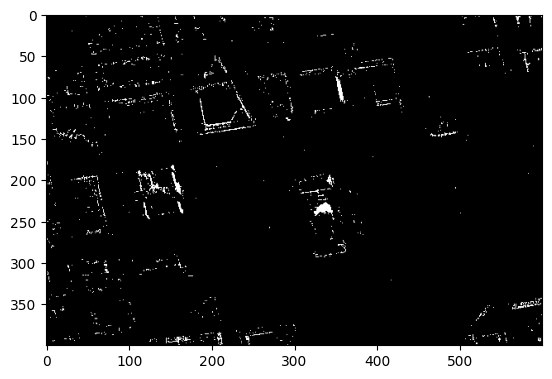

In [12]:
ret, image_thresh = cv.threshold(image, 200, 255, cv.THRESH_BINARY)
plt.imshow(image_thresh, cmap='gray')
ret

7.0

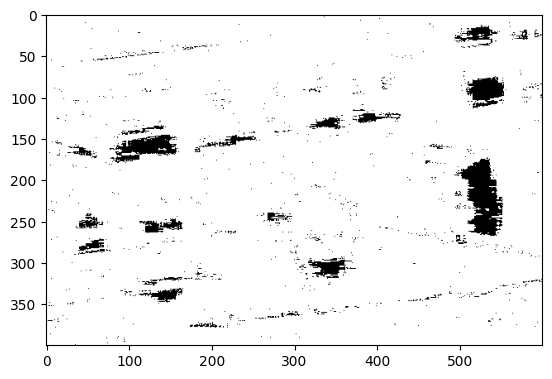

In [13]:
ret, image_thresh = cv.threshold(image, 7, 255, cv.THRESH_BINARY)
plt.imshow(image_thresh, cmap='gray')
ret